## UCAP STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

ucap=pd.read_csv('../stock_data/ucap.csv') ## so it can be small letter. This is cool.
ucap=ucap.drop(columns=['high_price','low_price'])
ucap.rename(columns={'trade_date':'date'},inplace=True)
ucap['date']=pd.to_datetime(ucap['date'])
ucap['month']=ucap['date'].dt.month
ucap['quarter']=ucap['date'].dt.quarter
ucap['year']=ucap['date'].dt.year

ucap

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42829,UCAP,2017-01-03,2.81,2.81,7937852,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43389,UCAP,2017-01-04,2.89,2.89,6707200,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43499,UCAP,2017-01-05,2.88,2.88,11036822,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43609,UCAP,2017-01-06,3.02,3.02,8993317,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43699,UCAP,2017-01-09,3.31,3.31,19658337,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298146,UCAP,2026-07-13,17.75,17.75,5012859,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298584,UCAP,2026-07-14,17.75,17.75,2043880,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,299022,UCAP,2026-07-15,17.75,17.75,5432174,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299460,UCAP,2026-07-16,17.50,17.50,5366137,2026-07-16T15:10:03.113936+00:00,7,3,2026


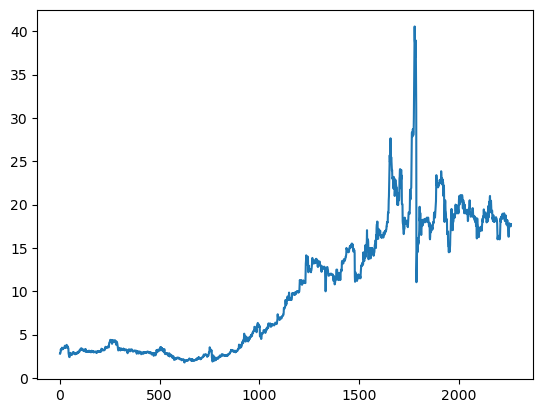

In [2]:
import matplotlib.pyplot as plt

plt.plot(ucap['close_price'])
plt.show()

In [3]:
ucap_end_month_df = (
    ucap
    .sort_values("date")
    .groupby(ucap["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

ucap_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45399,UCAP,2017-01-31,3.50,3.50,10116003,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47221,UCAP,2017-02-28,3.53,3.53,15691732,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49337,UCAP,2017-03-31,2.81,2.81,4964089,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51164,UCAP,2017-04-28,2.87,2.87,2463552,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53087,UCAP,2017-05-31,3.20,3.20,4678761,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35383,UCAP,2026-03-31,18.35,18.35,7731688,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281209,UCAP,2026-04-30,18.40,18.40,21446974,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284275,UCAP,2026-05-29,19.00,19.00,15993336,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294203,UCAP,2026-06-30,16.80,16.80,11113700,2026-06-30T15:10:03.08168+00:00,6,2,2026


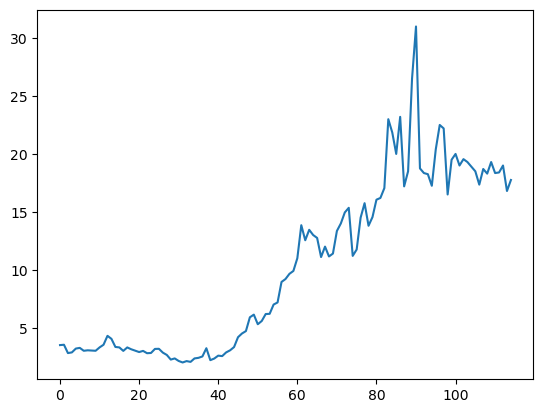

In [4]:
plt.plot(ucap_end_month_df['close_price'])
plt.show()

In [5]:
ucap_end_month_df['returns']=ucap_end_month_df['close_price'].pct_change()*100
ucap_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45399,UCAP,2017-01-31,3.50,3.50,10116003,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47221,UCAP,2017-02-28,3.53,3.53,15691732,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.857143
2,49337,UCAP,2017-03-31,2.81,2.81,4964089,2026-04-08T02:45:42.281198+00:00,3,1,2017,-20.396601
3,51164,UCAP,2017-04-28,2.87,2.87,2463552,2026-04-08T02:51:55.619599+00:00,4,2,2017,2.135231
4,53087,UCAP,2017-05-31,3.20,3.20,4678761,2026-04-08T02:52:57.421655+00:00,5,2,2017,11.498258
...,...,...,...,...,...,...,...,...,...,...,...
110,35383,UCAP,2026-03-31,18.35,18.35,7731688,2026-03-31T15:00:02.085058+00:00,3,1,2026,-4.922280
111,281209,UCAP,2026-04-30,18.40,18.40,21446974,2026-04-30T15:00:02.170664+00:00,4,2,2026,0.272480
112,284275,UCAP,2026-05-29,19.00,19.00,15993336,2026-05-29T15:00:02.455558+00:00,5,2,2026,3.260870
113,294203,UCAP,2026-06-30,16.80,16.80,11113700,2026-06-30T15:10:03.08168+00:00,6,2,2026,-11.578947


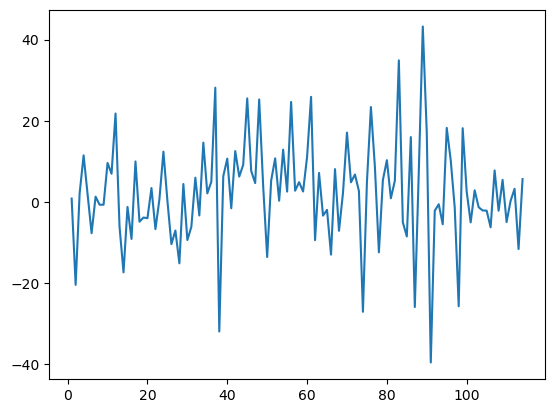

In [6]:
plt.plot(ucap_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(ucap_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-9.773892847842669, 7.017849702626566e-17, 1, 112, {'1%': -3.4901313156261384, '5%': -2.8877122815688776, '10%': -2.5807296460459184}, 795.479820823501)
stationary


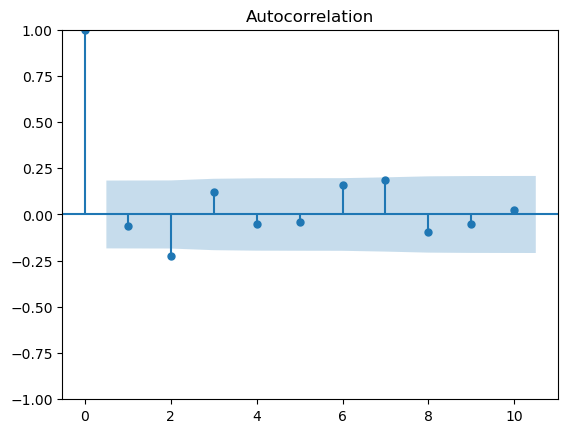

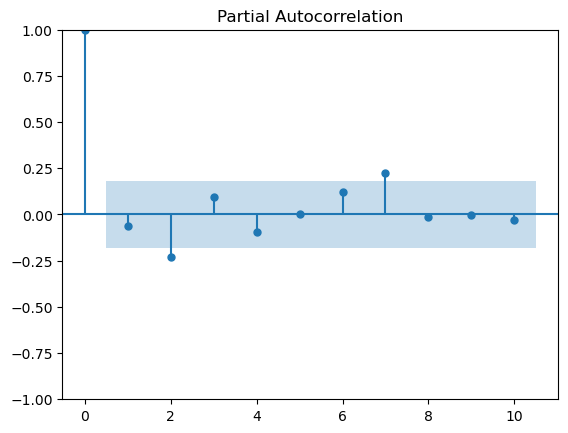

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(ucap_end_month_df['returns'].dropna(), lags=10)
plot_pacf(ucap_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [ ]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=ucap_end_month_df['close_price'][:-10]
test=ucap_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -5.720894646227309]
[0, 0, 0, 0, 0, 1, -3.7636985205484725]
[0, 0, 0, 0, 0, 2, -3.000440518426948]
[0, 0, 0, 0, 1, 0, -2.7514343084601256]
[0, 0, 0, 0, 1, 1, -2.5681467030089578]
[0, 0, 0, 0, 1, 2, -2.470481475449237]
[0, 0, 0, 0, 2, 0, -1.819152802351066]
[0, 0, 0, 0, 2, 1, -1.9509878401625826]
[0, 0, 0, 0, 2, 2, -1.9197654950321965]
[0, 0, 0, 1, 0, 0, -2.8767880813024966]
[0, 0, 0, 1, 0, 1, -2.7367711001771906]
[0, 0, 0, 1, 0, 2, -2.697899270567453]
[0, 0, 0, 1, 1, 0, -2.5225612049472015]
[0, 0, 0, 1, 1, 1, -2.522708836808469]
[0, 0, 0, 1, 1, 2, -2.362596290809949]
[0, 0, 0, 1, 2, 0, -1.9599453849521522]
[0, 0, 0, 1, 2, 1, -1.8748164705480033]
[0, 0, 0, 1, 2, 2, -1.9564052835387353]
[0, 0, 0, 2, 0, 0, -2.7314158821291703]
[0, 0, 0, 2, 0, 1, -2.729484483411064]
[0, 0, 0, 2, 0, 2, -2.559511893161371]
[0, 0, 0, 2, 1, 0, -2.5229828321929593]
[0, 0, 0, 2, 1, 1, -2.622269263965045]
[0, 0, 0, 2, 1, 2, -2.4925523161022576]
[0, 0, 0, 2, 2, 0, -1.86003770835562]
[0, 0, 0, 2,

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-5.720895
27,0,0,1,0,0,0,-5.603745
54,0,0,2,0,0,0,-5.523436
55,0,0,2,0,0,1,-4.079179
171,0,2,0,1,0,0,-4.072135
...,...,...,...,...,...,...,...
704,2,2,2,0,1,0,0.163385
706,2,2,2,0,1,2,0.163499
670,2,2,0,2,1,2,0.168301
705,2,2,2,0,1,1,0.179053


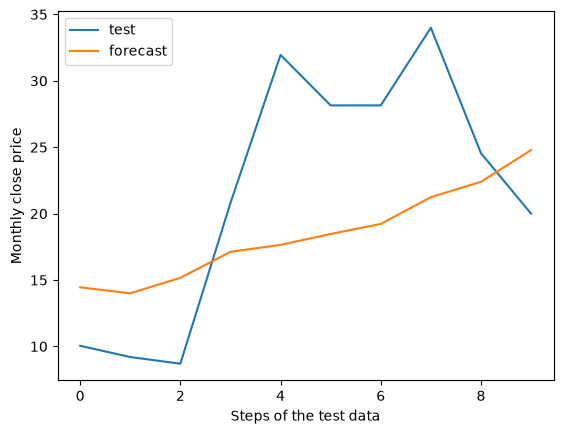

r2_score:  0.1797333815229475
rmse:  8.161943255927751
description:  count    115.000000
mean       5.758957
std        5.818487
min        2.060000
25%        3.300000
50%        4.050000
75%        5.240000
max       34.000000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=redstarex_end_month_df['close_price'][:-10]
y_test=redstarex_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,2), 
seasonal_order=(2,1,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', redstarex_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=redstarex_end_month_df['returns'].dropna()[:-10]
test=redstarex_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.07891364380636512]
[0, 0, 0, 0, 0, 1, -0.09989090937330203]
[0, 0, 0, 0, 0, 2, -0.055206199153820856]
[0, 0, 0, 0, 1, 0, -0.18839894273241176]
[0, 0, 0, 0, 1, 1, 0.033771086879622936]
[0, 0, 0, 0, 1, 2, 0.020274424179237416]
[0, 0, 0, 0, 2, 0, -1.5456430087947752]
[0, 0, 0, 0, 2, 1, -0.271535727437791]
[0, 0, 0, 0, 2, 2, -0.002962439034429387]
[0, 0, 0, 1, 0, 0, -0.11039022250298514]
[0, 0, 0, 1, 0, 1, -0.1249447747498802]
[0, 0, 0, 1, 0, 2, -0.07829059976009578]
[0, 0, 0, 1, 1, 0, 0.07522313507666978]
[0, 0, 0, 1, 1, 1, 0.019721238979336864]
[0, 0, 0, 1, 1, 2, 0.02129657796599327]
[0, 0, 0, 1, 2, 0, -0.2685019346565607]
[0, 0, 0, 1, 2, 1, 0.02871970612005703]
[0, 0, 0, 1, 2, 2, 0.032694016776987245]
[0, 0, 0, 2, 0, 0, -0.07333724596422053]
[0, 0, 0, 2, 0, 1, -0.07317876096103193]
[0, 0, 0, 2, 0, 2, -0.15061987583962555]
[0, 0, 0, 2, 1, 0, 0.0579344447032194]
[0, 0, 0, 2, 1, 1, 0.06191445654100103]
[0, 0, 0, 2, 1, 2, 0.021701565885729246]
[0, 0, 0, 2, 2, 0, -0.053

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
411,1,2,0,0,2,0,-23.217047
414,1,2,0,1,0,0,-22.033280
406,1,2,0,0,0,1,-21.955814
415,1,2,0,1,0,1,-21.539172
405,1,2,0,0,0,0,-20.982356
...,...,...,...,...,...,...,...
560,2,0,2,2,1,0,0.086260
551,2,0,2,1,1,0,0.086498
238,0,2,2,2,1,1,0.087570
120,0,1,1,1,1,0,0.088593


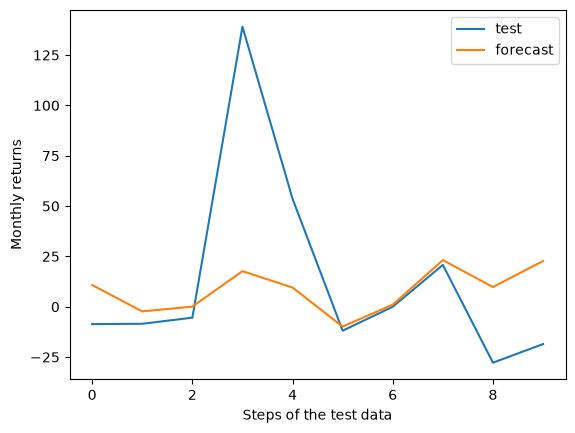

r2_score:  0.0926622038906657
rmse:  45.00253183162361
description:  count    114.000000
mean       2.733244
std       19.530750
min      -27.794118
25%       -7.554945
50%        0.000000
75%        8.193725
max      139.080460
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=redstarex_end_month_df['returns'].dropna()[:-10]
y_test=redstarex_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,0,2), 
seasonal_order=(2,1,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', redstarex_end_month_df.returns.dropna().describe())

Very horrible. We will work with close_price
